# Reinforcement Learning

Gebaseerd op https://blog.paperspace.com/getting-started-with-openai-gym/ - code is aangepast naar nieuwe returnvalues van bepaalde aangepaste functies.

### Installatie 

Installatie van de package blijkt niet zo eenvoudig. Ik suggereer sterk om een nieuwe conda omgeving aan te maken, omdat deze package een specifieke versie van python vergt en nog een paar andere dependencies. Volg het stappenplan hieronder.

Maak een nieuwe conda omgeving met een specifieke python versie (3.10), vergeet niet te activeren. Dus:
- `conda create --name rlearning python=3.10`
- `conda activate rlearning`
- `conda install -c conda-forge mamba` 
- `mamba install -c conda-forge gym-all`
- `mamba install ipykernel`
- `pip install gymnasium`
- `conda install matplotlib`
- `pip install "gymnasium[toy-text]"`
- `conda install tqdm`

Normaal zou bovenstaande voldoende moeten zijn.

Update:
- `pip install gymnasium`
- `sudo apt-get install build-essential swig`
- `conda install ipykernel`
- `pip install gymnasium[box2d]`
- `pip install moviepy`

## Voorbeeld: de mountain car
In dit voorbeeld leren we een kar een vlak te bereiken, door snel genoeg te rijden en naar beneden snelheid te maken
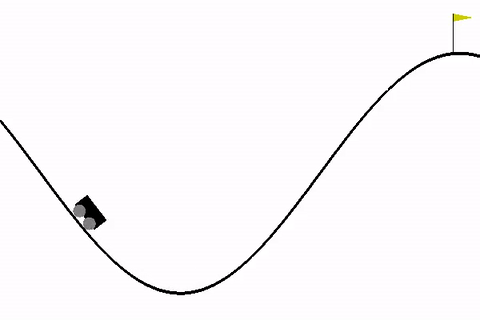

In [1]:
import gymnasium as gym
env = gym.make('MountainCar-v0', render_mode="rgb_array")

In de omgeving (environment) zitten attributen die je kan gebruiken:
- de observation_space: hier zitten de geldige waardes en de huidige waarde (state) van de omgeving. Beeld je dit in als een screenshot van de situatie.
- de action_space: hier zitten geldige acties die kunnen worden uitgevoerd.

In [2]:
# Observation en action space 
obs_space = env.observation_space
action_space = env.action_space
print("The observation space: {}".format(obs_space))
print("The action space: {}".format(action_space))

The observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
The action space: Discrete(3)


De observatieruimte is een vector van 2 getallen: snelheid en positie. Het midden tussen de twee bergen is daarbij (0,0) per conventie. De observation space is een Box, wat aangeeft dat de parameters alle waardes kunnen zijn in een 'rechthoek'. De actie is discreet, wat in dit geval betekent dat er 3 acties mogelijk zijn.

**Interageren met de omgeving**
Nu kunnen we interageren met de omgeving. Er zijn 2 belangrijke functies:
- reset: hiermee keer je terug naar de initiële status
- step: deze functie krijgt een actie als input, en voert die actie uit, waardoor de omgeving verandert. De step functie geeft veel variabelen terug:
    - observation: de state van de nieuwe environment
    - reward: de reward die bij deze nieuwe environment hoort na deze stap
    - terminated: boolean om aan te geven of dit experiment ten einde is
    - truncated: wanneer er conditie is gevonden die ook tot stoppen leidt, maar niet wenselijk is (out of bounds, een tijdslimiet overschreden)
    - info: extra informatie, hangt af van het soort omgeving. Dit kan nuttig zijn voor debugging.

In [3]:
import matplotlib.pyplot as plt 

# reset
obs = env.reset()
print("De initiële observatie is {}".format(obs))

# We kiezen een random actie
random_action = env.action_space.sample()

#Voer die actie ook effectief uit
new_obs, reward, terminated, truncated, info = env.step(random_action)
print("The new observation is {}".format(new_obs))

De initiële observatie is (array([-0.533745,  0.      ], dtype=float32), {})
The new observation is [-5.3366894e-01  7.6085074e-05]


Visuele output:

/home/bruno/miniconda3/envs/RL_env3/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
shm_open() failed: No such file or directory
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) 

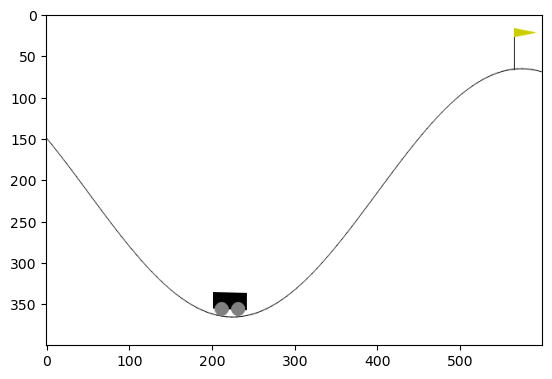

In [4]:
env_screen = env.render()
env.close()

import matplotlib.pyplot as plt 
plt.imshow(env_screen)

Nu kun je al iets in mekaar beginnen puzzelen. We starten met een agent die random acties uitvoert:

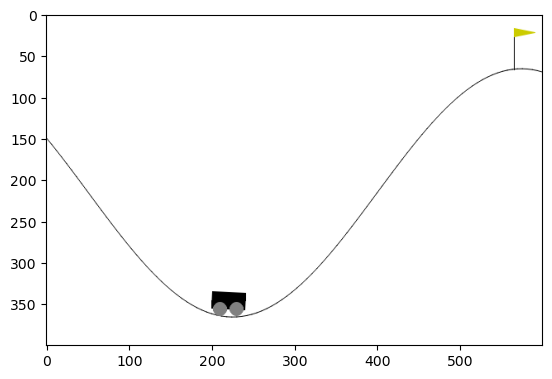

In [5]:
import time 
import matplotlib.pyplot as plt 
from gymnasium.utils.save_video import save_video

num_steps = 2500

obs = env.reset()
step_starting_index=0
episode_index=0
frames=[]
for step in range(num_steps):
    # random actie, iets beter kan eventueel later
    # action = my_intelligent_agent_fn(obs) 
    action = env.action_space.sample()
    
    # actie uitvoeren
    obs, reward,  terminated, truncated, info = env.step(action)
    
    # Renderen
    env_screen = env.render()
    # plt.imshow(env_screen)

    frames.append(env.render())

    # even wachten, anders gaat het zo snel dat je niks kan zien
    time.sleep(0.001)
    
    # indien doel bereikt of andere eindstaat, start opnieuw
    if terminated or truncated:
        save_video(
            frames=frames, 
            video_folder="./videos",
            fps=30,
            episode_index=episode_index
        )
        step_starting_index = step + 1
        episode_index += 1
        env.reset()

env.close()

plt.imshow(env_screen)

## [nog niet werkend] Een algoritme implementeren om zelf te leren: Q-learning

In [6]:
env.observation_space
env.observation_space.high

array([0.6 , 0.07], dtype=float32)

In [17]:
import numpy as np

# Voorbeeld:  Q-learning
Q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1 # learning rate. Als deze te hoog, te agressief is; kan er fluctuatie optreden
gamma = 0.99 # discounting parameter
epsilon = 0.1 # variable voor explore exploit tradeoff

# Training loop
for i_episode in range(2000):
    observation, info = env.reset()
    for t in range(100):
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Exploreer action space
        else:
            action = np.argmax(Q_table[observation])  # Exploiteer geleerde waardes
            
        next_observation, reward, done, _ = env.step(action)

        # Q-learning update
        old_value = Q_table[observation, action]
        next_max = np.max(Q_table[next_observation])

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max) # dit hebben we gezien in de theorie
        Q_table[observation, action] = new_value

        observation = next_observation
        if done:
            break


AttributeError: 'Box' object has no attribute 'n'

Dit werkt niet, omdat de observation space continu is en niet discreet. We moeten deze eerst nog omvormen naar een discrete ruimte:

In [8]:
env.observation_space
#env.action_space.n

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Een box is een product van gesloten intervallen (zie https://gymnasium.farama.org/api/spaces/fundamental/). Als je een box hebt, wat een continu spectrum is, moet je dit via **discretisatie** omzetten naar een eindig aantal opties (discrete set opties).

In [9]:
import numpy as np

env
observation_space = env.observation_space

# Discretisatie: het opdelen van een continue  box in stukjes
bins = [10, 10]  # we kiezen 10 bins voor elk van de 2 dimensies

def discretize_observation(observation, bins):
    observation = np.array(observation)

    # normalisatie
    normalized_observation = (observation - observation_space.low) / (observation_space.high - observation_space.low)

    # mapping naar bins
    discretized_observation = np.floor(normalized_observation * np.array(bins)).astype(int)

    # clipping: zorgen dat observatie binnen de range valt
    discretized_observation = np.clip(discretized_observation, 0, np.array(bins) - 1)
    return discretized_observation

In [10]:
observation, info = env.reset()
discretized_observation = discretize_observation(observation, bins)
print("Original observation:", observation)
print("Discretized observation:", discretized_observation)

Original observation: [-0.57041514  0.        ]
Discretized observation: [3 5]


Debugging


In [11]:
print("Observation space low:", observation_space.low)
print("Observation space high:", observation_space.high)


Observation space low: [-1.2  -0.07]
Observation space high: [0.6  0.07]


In [12]:
print("Discretized observation:", discretized_observation)
print("Bins:", bins)


Discretized observation: [3 5]
Bins: [10, 10]


In [13]:
env.action_space.n

3

In [14]:
env.action_space.sample()

2

In [18]:
env.action_space.dtype

dtype('int64')

## [nog niet werkend] Q-learning revisited

Note to self: hier is nog iets mis met de dimensies van de matrices, maar dit zou zeer oplosbaar moeten zijn. 

In [20]:
import numpy as np

# Voorbeeld:  Q-learning
observation, info = env.reset()
Q_table = np.zeros(tuple(bins) + (env.action_space.n,))



# Hyperparameters
alpha = 0.1 # learning rate. Als deze te hoof, te agressief is; kan er fluctuatie optreden
gamma = 0.99 # discounting parameter
epsilon = 0.1 # variable voor explore exploit tradeoff

#discretizatie parameter
bins = [10,10]

# Training loop
for i_episode in range(2000):
    observation, info = env.reset()
    for t in range(100):
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Exploreer action space
            assert action in range(env.action_space.n), f"Invalid action with random pick: {action}"

        else:
            action = np.argmax(Q_table[discretize_observation(observation, bins)]) # Exploiteer geleerde waardes
            print("dtype action: ", action.dtype)
            assert action in range(env.action_space.n), f"Invalid action with argmax: {action}"

            
        next_observation, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning update
        old_value = Q_table[discretize_observation(observation, bins), action]
        next_max = np.max(Q_table[discretize_observation(next_observation, bins)])

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max) # dit hebben we gezien in de theorie
        Q_table[discretize_observation(observation, bins), action] = new_value

        observation = next_observation
        print("end of loop")
        if done:
            break


end of loop
dtype action:  int64
end of loop
dtype action:  int64


AssertionError: Invalid action with argmax: 6

### Meer over Q-learning: hoe kom je aan deze formule ?

De totale reward op een tijdstip $t$, genoteerd $R_t$, is de som waarbij rewards die verder in de tijd liggen met een factor $\gamma$ worden vermenigvuldigd (worden dus iets kleiner).
$$
R_t = r_{t+1} + \gamma \cdot r_{t+2} + \gamma^2 \cdot  r_{t+3} + \ldots
= \sum_{k=0}^{\infty} \gamma^k \cdot  r_{t+k+1}
$$

We kijken nu naar de fout tussen de échte, ideale predictie $V_t^*$ en de predictie die we hebben $V_t$:

$$
E_t = V_t^* - V_T
$$
$$
E_t =  r_{t+1} + \sum_{k=1}^{\infty} \gamma^k \cdot  r_{t+k+1} - V_t
$$
$$
E_t =  r_{t+1} + \gamma \sum_{k=1}^{\infty} \gamma^{k-1} \cdot  r_{t+k+1} - V_t
$$
$$
E_t =  r_{t+1} + \gamma \sum_{k=0}^{\infty} \gamma^{k} \cdot  r_{(t+1)+k+1} - V_t
$$
$$
E_t =  r_{t+1} + \gamma \cdot  V_{t+1} - V_t
$$

Hieruit kunnen we de update strategie halen als de nieuwe waarde de oude waarde is, maar dan aangepast met deze error term, vermenigvuldigd met de learning rate $\alpha$.
```
new_value = old_value + alpha * error
```


$$
V_t := V_t + \alpha \cdot E_t \\
\phantom{spacing spacing sp} V_t := V_t + \alpha \cdot (r_{t+1} + \gamma \cdot V_{t+1} - V_t)
$$

## Taxi


In [4]:
import time

env = gym.make('Taxi-v3', render_mode="rgb_array")

print("Observation Space: ", env.observation_space)
print("Action Space       ", env.action_space)


obs = env.reset()

for i in range(1000):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    time.sleep(0.01)
env.close()

Observation Space:  Discrete(500)
Action Space        Discrete(6)


shm_open() failed: No such file or directory
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5180:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5703:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2666:(snd_pcm_open_noupdate) Unknown PCM default


Hier is discretisatie niet nodig, we kunnen meteen Q-learning toepassen:

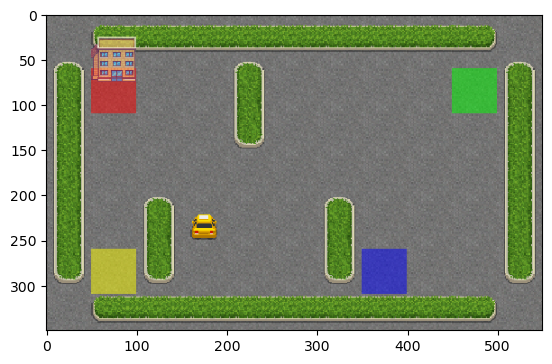

In [6]:
import matplotlib.pyplot as plt

env_screen = env.render()
plt.imshow(env_screen)

Nu even rondstappen naar het noorden (dit is ingebouwd als code 1):

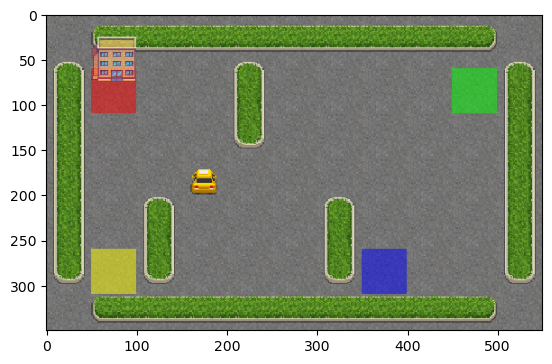

In [7]:
env.step(1)
env_screen = env.render()
plt.imshow(env_screen)

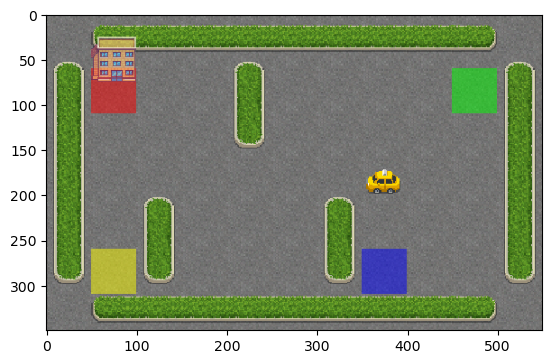

In [8]:
#env.step(4)
env.step(2)
env.step(2)
env.step(2)
env.step(3)
env.step(2)
env.step(2)
env.step(3)
env_screen = env.render()
plt.imshow(env_screen)

In [9]:
import numpy as np

# Voorbeeld:  Q-learning
Q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1 # learning rate. Als deze te hoog, te agressief is; kan er fluctuatie optreden
gamma = 0.99 # discounting parameter
epsilon = 0.1 # variable voor explore exploit tradeoff

# Training loop
for i_episode in range(2000):
    observation, info = env.reset()
    for t in range(100):
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Exploreer action space
        else:
            action = np.argmax(Q_table[observation])  # Exploiteer geleerde waardes
            
        next_observation, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning update
        old_value = Q_table[observation, action]
        next_max = np.max(Q_table[next_observation])

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max) # dit hebben we gezien in de theorie
        Q_table[observation, action] = new_value

        observation = next_observation
        if done:
            break


# Taxi met Q-table reinforcement learning
In de taxiomgeving zijn er vooral penalties, dus de reward zal veelal negatief zijn.

In [10]:
import gymnasium as gym

# Initialize the Gym environment
env = gym.make('Taxi-v3')

# Print the observation and action space details
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

# Reset the environment and observe the initial state
initial_state = env.reset()
print("Initial state:", initial_state)

# Take a manual step in the environment
action = env.action_space.sample()  # Sample a random action
new_state, reward, terminated, truncated, _ = env.step(action)
print("Action taken:", action)
print("New state after taking action:", new_state)
print("Reward received:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)


Observation space: Discrete(500)
Action space: Discrete(6)
Initial state: (141, {'prob': 1.0, 'action_mask': array([1, 1, 1, 0, 0, 0], dtype=int8)})
Action taken: 1
New state after taking action: 41
Reward received: -1
Terminated: False
Truncated: False


### Q-tabel algoritme met plot

Deze code toont een intelligent agent met zelflerend gedrag, zoals gezien in de les over reinforcement learning. De agent wordt gaandeweg beter in het oppikken van rewards. Het centrale onderdeel in dit algoritme is het 'Q-learning algoritme'. Dit werkt als volgt:

**Initialisatie van de Q-tabel**
- Maakt een Q-tabel aan met nullen, bedoeld voor het bijhouden van beloningen.

**Instellen van Q-learning Parameters**
- Stelt leerparameters in zoals `learning_rate`, `discount_factor`, `num_episodes`, en `max_steps_per_episode`.

**Q-learning Algoritme**
- *Loop door Episodes:* elke episode begint met het resetten van de omgeving.
- *Handeling:* kiest tussen exploratie en exploitatie, waarbij de kans op exploratie afneemt naarmate er meer episodes zijn voltooid.
- *Actie en Observatie:* voert een actie uit en observeert de uitkomst en beloning.
- *Update van de Q-tabel:* past de Q-tabel aan op basis van de ontvangen beloning.

In essentie is de Q-tabel een lijst van 'locaties' in state-space waar een beloning werd gevonden.

**Beloningen Opslaan en Analyseren**
- Slaat de beloningen op en berekent de gemiddelde beloning over alle episodes.

**Resultaten Plotten**
- Toont een grafiek van de beloningen per episode over tijd.


Average Reward: -217.208


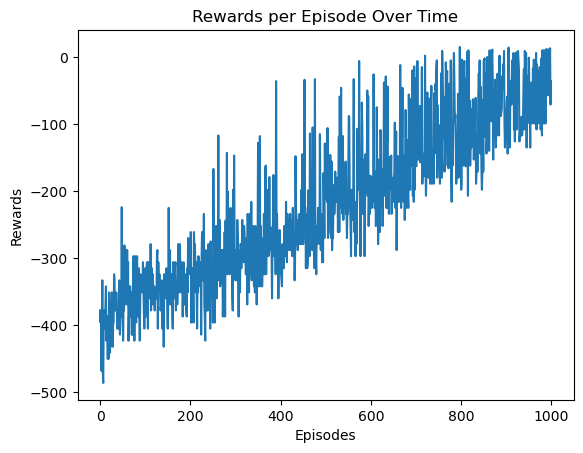

In [11]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Omgeving opzetten
env = gym.make('Taxi-v3')

# Initialisatie the Q-table
Q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Q-learning parameters
learning_rate = 0.1
discount_factor = 0.9
num_episodes = 1000
max_steps_per_episode = 99

# om later matrices te plotten
rewards_all_episodes = []

# Q-learning algoritme
for episode in range(num_episodes):
    initial_state = env.reset()
    state = initial_state[0] if isinstance(initial_state, tuple) else initial_state  # integer eruit vissen
    total_rewards = 0

    for step in range(max_steps_per_episode):
        # Exploratie vs exploitatie
        exploration_rate = 1 - episode / num_episodes # in het begin een veel grotere kans op exploratie
        #exploration_rate = np.exp(-episode/num_episodes)
        if np.random.uniform(0, 1) < exploration_rate:
            action = env.action_space.sample() # random kiezen, exploratie
        else:
            action = np.argmax(Q_table[state, :]) # doe de beste gekende actie

        # Actie uitvoeren, resultaat observeren
        new_state, reward, terminated, truncated, _ = env.step(action)

        # Update Q-table
        Q_table[state, action] = Q_table[state, action] * (1 - learning_rate) + \
                                 learning_rate * (reward + discount_factor * np.max(Q_table[new_state, :]))

        total_rewards += reward
        state = new_state

        if terminated or truncated:
            break

    rewards_all_episodes.append(total_rewards)

# berekening en prints
average_reward = sum(rewards_all_episodes) / num_episodes
print(f"Average Reward: {average_reward}")

# Plotting the learning progress
plt.plot(rewards_all_episodes)
plt.xlabel('Episodes')
plt.ylabel('Rewards')
plt.title('Rewards per Episode Over Time')
plt.show()


### Bronnen
Meer weten ? Bekijk onderstaande links

- https://blog.paperspace.com/getting-started-with-openai-gym/
- https://towardsdatascience.com/intro-to-reinforcement-learning-temporal-difference-learning-sarsa-vs-q-learning-8b4184bb4978
- https://towardsdatascience.com/reinforcement-learning-teach-a-taxi-cab-to-drive-around-with-q-learning-9913e611028f